Generating Phase 21 Master Thesis Evaluation Artifacts...


C:\Users\waliu\AppData\Local\Temp\ipykernel_23076\784680848.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


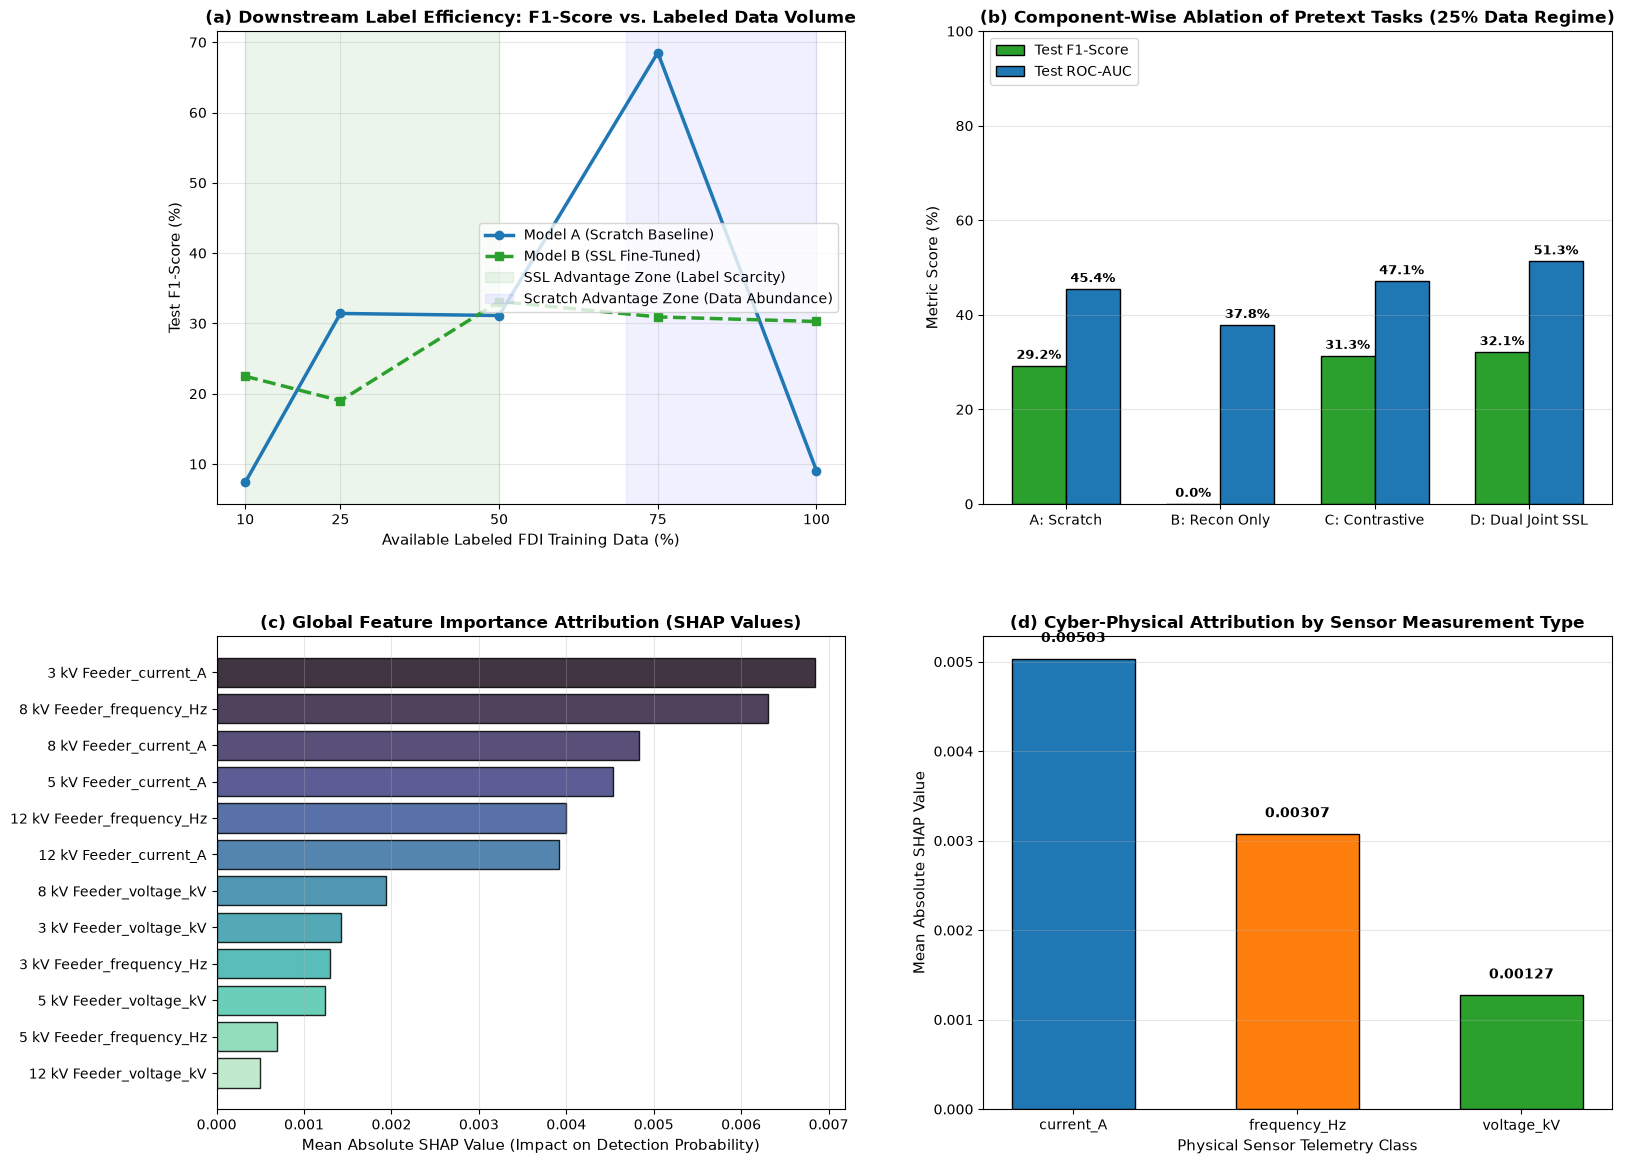

[SUCCESS] Saved Master Synthesis Figure to: ..\results\figures\phase21_master_thesis_evaluation.png


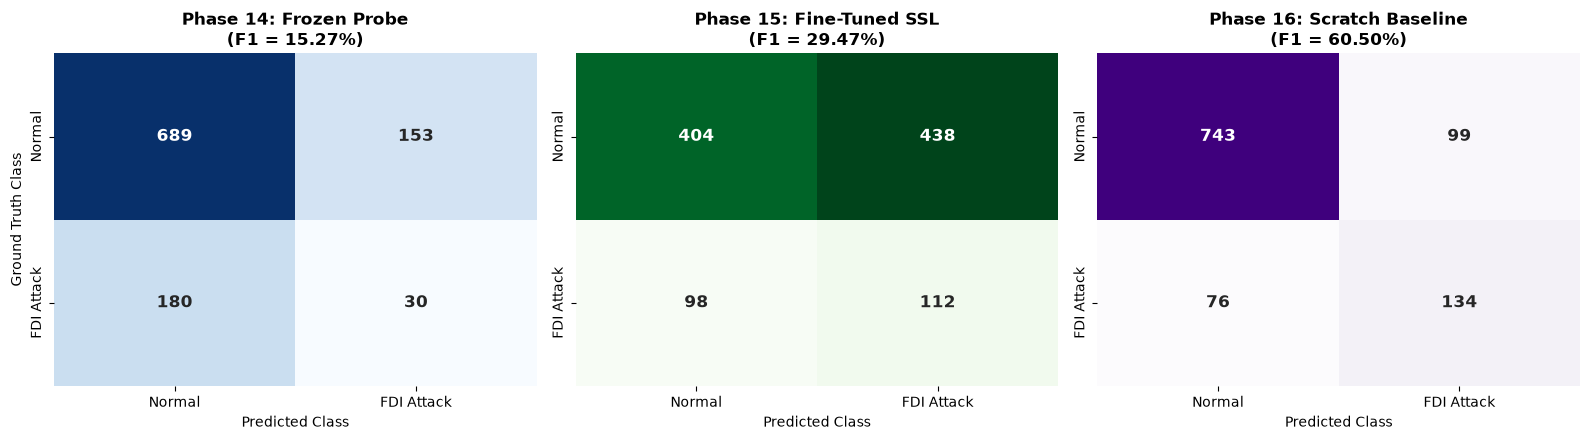

[SUCCESS] Saved Master Confusion Matrix Suite to: ..\results\figures\phase21_master_confusion_matrices.png


In [1]:
# notebooks/18_phase21_final_evaluation.ipynb

import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

print("Generating Phase 21 Master Thesis Evaluation Artifacts...")

results_dir = Path('../results')
fig_dir = Path('../results/figures')
fig_dir.mkdir(parents=True, exist_ok=True)

# -------------------------------------------------------------------------
# Figure 1: 4-Panel Master Empirical Benchmark Figure
# -------------------------------------------------------------------------
fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(2, 2, hspace=0.28, wspace=0.22)

# Panel A: Label-Efficiency Trajectory (F1 vs % Labels)
ax1 = fig.add_subplot(gs[0, 0])
df_limited = pd.read_csv(results_dir / 'phase17_limited_label_results.csv')
fractions = [10, 25, 50, 75, 100]

ax1.plot(fractions, df_limited['scratch_f1'], marker='o', lw=2.5, color='#1f77b4', label='Model A (Scratch Baseline)')
ax1.plot(fractions, df_limited['ssl_f1'], marker='s', lw=2.5, color='#2ca02c', linestyle='--', label='Model B (SSL Fine-Tuned)')
ax1.axvspan(10, 50, color='green', alpha=0.08, label='SSL Advantage Zone (Label Scarcity)')
ax1.axvspan(70, 100, color='blue', alpha=0.06, label='Scratch Advantage Zone (Data Abundance)')
ax1.set_title('(a) Downstream Label Efficiency: F1-Score vs. Labeled Data Volume', fontsize=12, fontweight='bold')
ax1.set_xlabel('Available Labeled FDI Training Data (%)', fontsize=11)
ax1.set_ylabel('Test F1-Score (%)', fontsize=11)
ax1.set_xticks(fractions)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='center right', fontsize=10)

# Panel B: Component Ablation Study Comparison (25% Labels)
ax2 = fig.add_subplot(gs[0, 1])
df_ablation = pd.read_csv(results_dir / 'phase18_ablation_results.csv')
x = np.arange(len(df_ablation))
width = 0.35

ax2.bar(x - width/2, df_ablation['F1-Score'], width, label='Test F1-Score', color='#2ca02c', edgecolor='black')
ax2.bar(x + width/2, df_ablation['ROC-AUC'], width, label='Test ROC-AUC', color='#1f77b4', edgecolor='black')
ax2.set_title('(b) Component-Wise Ablation of Pretext Tasks (25% Data Regime)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Metric Score (%)', fontsize=11)
ax2.set_xticks(x)
ax2.set_xticklabels(['A: Scratch', 'B: Recon Only', 'C: Contrastive', 'D: Dual Joint SSL'], fontsize=10)
ax2.set_ylim(0, 100)
ax2.grid(axis='y', alpha=0.3)
ax2.legend(loc='upper left', fontsize=10)

for i in range(len(df_ablation)):
    ax2.text(i - width/2, df_ablation['F1-Score'][i] + 1.5, f"{df_ablation['F1-Score'][i]:.1f}%", ha='center', fontsize=9, fontweight='bold')
    ax2.text(i + width/2, df_ablation['ROC-AUC'][i] + 1.5, f"{df_ablation['ROC-AUC'][i]:.1f}%", ha='center', fontsize=9, fontweight='bold')

# Panel C: Global Feature Importance (SHAP Value Ranking)
ax3 = fig.add_subplot(gs[1, 0])
df_shap = pd.read_csv(results_dir / 'phase19_shap_feature_importance.csv')
palette = sns.color_palette("mako_r", len(df_shap))
ax3.barh(df_shap['Feature'][::-1], df_shap['Mean_Abs_SHAP'][::-1], color=palette, edgecolor='black', alpha=0.85)
ax3.set_title('(c) Global Feature Importance Attribution (SHAP Values)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Mean Absolute SHAP Value (Impact on Detection Probability)', fontsize=11)
ax3.grid(axis='x', alpha=0.3)

# Panel D: Physical Measurement Type Attribution Breakdown
ax4 = fig.add_subplot(gs[1, 1])
grouped_meas = df_shap.groupby('Measurement', as_index=False)['Mean_Abs_SHAP'].mean()
colors_meas = ['#1f77b4', '#ff7f0e', '#2ca02c']
bars = ax4.bar(grouped_meas['Measurement'], grouped_meas['Mean_Abs_SHAP'], color=colors_meas, edgecolor='black', width=0.55)
ax4.set_title('(d) Cyber-Physical Attribution by Sensor Measurement Type', fontsize=12, fontweight='bold')
ax4.set_ylabel('Mean Absolute SHAP Value', fontsize=11)
ax4.set_xlabel('Physical Sensor Telemetry Class', fontsize=11)
ax4.grid(axis='y', alpha=0.3)

for bar in bars:
    yval = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2.0, yval + 0.00015, f"{yval:.5f}", ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
master_fig_path = fig_dir / 'phase21_master_thesis_evaluation.png'
plt.savefig(master_fig_path, dpi=300)
plt.show()
print(f"[SUCCESS] Saved Master Synthesis Figure to: {master_fig_path}")

# -------------------------------------------------------------------------
# Figure 2: Master Confusion Matrices Comparison (3 Models)
# -------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

cms = [
    (np.array([[689, 153], [180, 30]]), 'Phase 14: Frozen Probe\n(F1 = 15.27%)', 'Blues'),
    (np.array([[404, 438], [98, 112]]), 'Phase 15: Fine-Tuned SSL\n(F1 = 29.47%)', 'Greens'),
    (np.array([[743, 99], [76, 134]]), 'Phase 16: Scratch Baseline\n(F1 = 60.50%)', 'Purples')
]

for idx, (cm_data, title, cmap) in enumerate(cms):
    sns.heatmap(cm_data, annot=True, fmt='d', cmap=cmap, cbar=False, ax=axes[idx],
                xticklabels=['Normal', 'FDI Attack'], yticklabels=['Normal', 'FDI Attack'],
                annot_kws={'size': 12, 'weight': 'bold'})
    axes[idx].set_title(title, fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted Class', fontsize=10)
    if idx == 0:
        axes[idx].set_ylabel('Ground Truth Class', fontsize=10)
    else:
        axes[idx].set_ylabel('')

plt.tight_layout()
cm_master_path = fig_dir / 'phase21_master_confusion_matrices.png'
plt.savefig(cm_master_path, dpi=300)
plt.show()
print(f"[SUCCESS] Saved Master Confusion Matrix Suite to: {cm_master_path}")